# Learned Embeddings — Pretrained vs Random Encoder

Extract the 256-dim dual-pool representation from both conditions and visualise with t-SNE. The key question: does pretraining produce a representation space that separates species better than random initialisation?

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..').resolve()))
import chroma_dcnn
sys.modules.setdefault('msformer', chroma_dcnn)
import chroma_dcnn.models
import chroma_dcnn.training

from chroma_dcnn.models.chroma_cnn import ChromatogramCNN, ChromaCNNConfig

DATA_DIR  = Path('../data/fish_oil')
CKPT_PATH = Path('../checkpoints/chroma_pretrain/best.pt')
DEVICE    = torch.device('cpu')

SPECIES = {0: 'SNA', 1: 'GUR', 2: 'TAR', 3: 'BCO'}
COLOURS = {0: '#2196f3', 1: '#ff9800', 2: '#4caf50', 3: '#e91e63'}

y = np.load(DATA_DIR / 'y.npy')
npz_paths = sorted((DATA_DIR / 'chroma').glob('*.npz'))
print(f'Samples: {len(npz_paths)}   Classes: {np.unique(y)}')

Samples: 103   Classes: [0 1 2 3]


In [2]:
# ── Load all chromatograms ────────────────────────────────────────────────────
chromas = np.stack([np.load(p)['chroma'] for p in npz_paths])  # [N, 200, 1000]
X_t = torch.tensor(chromas, dtype=torch.float32)                # [N, 200, 1000]
print(f'Input tensor: {X_t.shape}')

Input tensor: torch.Size([103, 200, 1000])


In [3]:
# ── Embedding extractor ───────────────────────────────────────────────────────
@torch.no_grad()
def extract_embeddings(model, X):
    """Return [N, 256] dual-pool embeddings (before the classification head)."""
    model.eval()
    B, N, mz = X.shape
    emb  = model.spec_proj(X.reshape(B * N, mz)).view(B, N, -1)  # [B, N, 128]
    feat = model.cnn(emb.transpose(1, 2))                          # [B, 128, N]
    x_max  = feat.max(dim=-1).values                               # [B, 128]
    x_attn = model.attn_pool(feat)                                 # [B, 128]
    return torch.cat([x_max, x_attn], dim=-1).numpy()              # [B, 256]

cfg = ChromaCNNConfig(mz_max=1000, cnn_channels=128, kernel_size=7,
                      num_classes=4, dropout=0.3)

# Random (from-scratch) encoder
torch.manual_seed(0)
model_rand = ChromatogramCNN(cfg).to(DEVICE)
emb_rand   = extract_embeddings(model_rand, X_t)

# Pretrained encoder
model_pre = ChromatogramCNN(cfg).to(DEVICE)
model_pre.load_pretrained_chroma_encoder(str(CKPT_PATH))
emb_pre   = extract_embeddings(model_pre, X_t)

print(f'Random embeddings:    {emb_rand.shape}')
print(f'Pretrained embeddings:{emb_pre.shape}')

  Loaded pretrained spec_proj from ../checkpoints/chroma_pretrain/best.pt
  Loaded pretrained CNN from ../checkpoints/chroma_pretrain/best.pt


Random embeddings:    (103, 256)
Pretrained embeddings:(103, 256)


## t-SNE projections

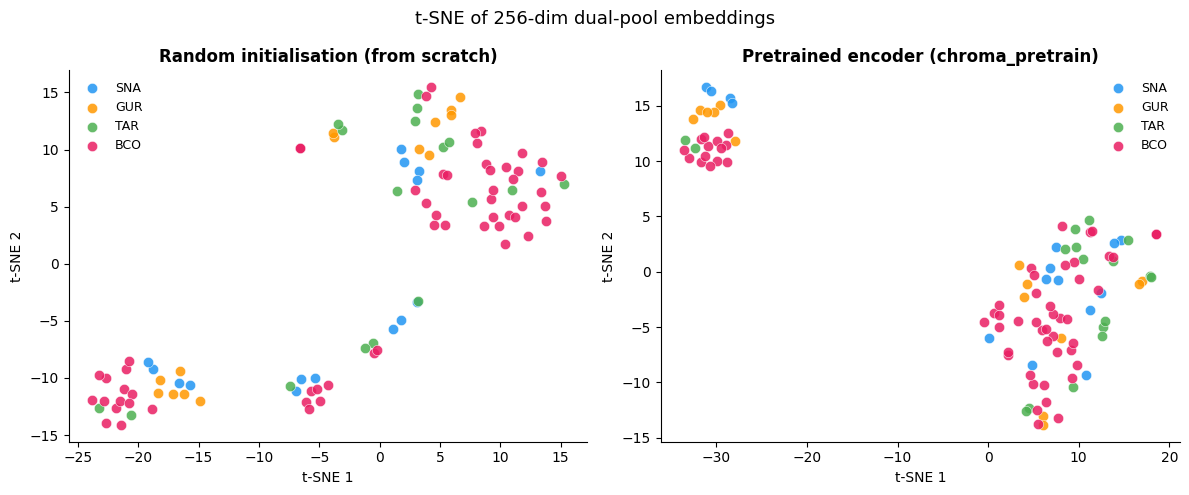

In [4]:
from sklearn.manifold import TSNE

tsne_rand = TSNE(n_components=2, random_state=42, perplexity=15).fit_transform(emb_rand)
tsne_pre  = TSNE(n_components=2, random_state=42, perplexity=15).fit_transform(emb_pre)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, emb_2d, title in zip(
        axes,
        [tsne_rand, tsne_pre],
        ['Random initialisation (from scratch)', 'Pretrained encoder (chroma_pretrain)']):

    for c in range(4):
        mask = y == c
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                   c=COLOURS[c], label=SPECIES[c],
                   s=55, alpha=0.85, edgecolors='white', linewidths=0.4)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(frameon=False, fontsize=9)
    sns.despine(ax=ax)

plt.suptitle('t-SNE of 256-dim dual-pool embeddings', fontsize=13)
plt.tight_layout()
plt.show()

## Linear separability: silhouette score

Silhouette score — random:     -0.032
Silhouette score — pretrained: -0.080
Improvement: -0.048


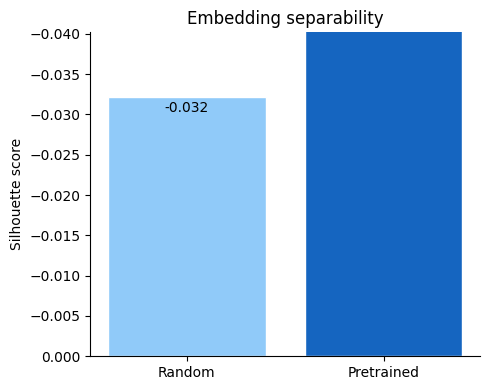

In [5]:
from sklearn.metrics import silhouette_score

sil_rand = silhouette_score(emb_rand, y)
sil_pre  = silhouette_score(emb_pre,  y)

print(f'Silhouette score — random:     {sil_rand:.3f}')
print(f'Silhouette score — pretrained: {sil_pre:.3f}')
print(f'Improvement: {sil_pre - sil_rand:+.3f}')

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Random', 'Pretrained'], [sil_rand, sil_pre],
              color=['#90caf9', '#1565c0'], edgecolor='white')
ax.bar_label(bars, fmt='{:.3f}', padding=3)
ax.set_ylabel('Silhouette score')
ax.set_title('Embedding separability')
ax.set_ylim(0, max(sil_rand, sil_pre) * 1.25)
sns.despine()
plt.tight_layout()
plt.show()